In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import matplotlib.pyplot as plt

In [2]:
metrics_distributed = pickle.load(open("./federated_learning_history_metrics_distributed.pkl", "rb"))

In [4]:
metrics_private = pickle.load(open("./private_learning_history_metric.pkl", "rb"))

In [23]:
iteration = 49
metric = 'mae'

for metric in ['mae', 'mse', 'rmse']:
    results_df = pd.DataFrame(index=range(10), columns=['federated_learning', 'private_learning'])

    results_df['federated_learning'] = metrics_distributed[metric][iteration][1]
    results_df['private_learning'] = [metrics_private[iteration][i][2][metric] for i in range(10)]
    # compute an average row
    results_df.loc['average'] = results_df.mean()
    print(f"Results for metric: {metric}")
    print(results_df)

Results for metric: mae
         federated_learning  private_learning
0                  0.046718          0.051820
1                  0.069692          0.089857
2                  0.087349          0.085018
3                  0.051654          0.082641
4                  0.052872          0.060480
5                  0.052872          0.057558
6                  0.087625          0.050060
7                  0.052216          0.050469
8                  0.060174          0.075865
9                  0.076112          0.061233
average            0.063728          0.066500
Results for metric: mse
         federated_learning  private_learning
0                  0.004324          0.007069
1                  0.012483          0.016923
2                  0.015296          0.012520
3                  0.006124          0.016979
4                  0.006831          0.008962
5                  0.006743          0.006965
6                  0.016697          0.006955
7                  0.007143     

In [19]:
from ts_inverse.client import TimeSeriesClient
from copy import deepcopy

clients = pickle.load(open("./private_clients.pkl", "rb"))

In [22]:
metric = 'mae'

results_matrix = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        data_source_client = deepcopy(clients[i])
        results_matrix[i, j] = round(data_source_client.evaluate(clients[j].get_parameters(), {})[2][metric], 4)

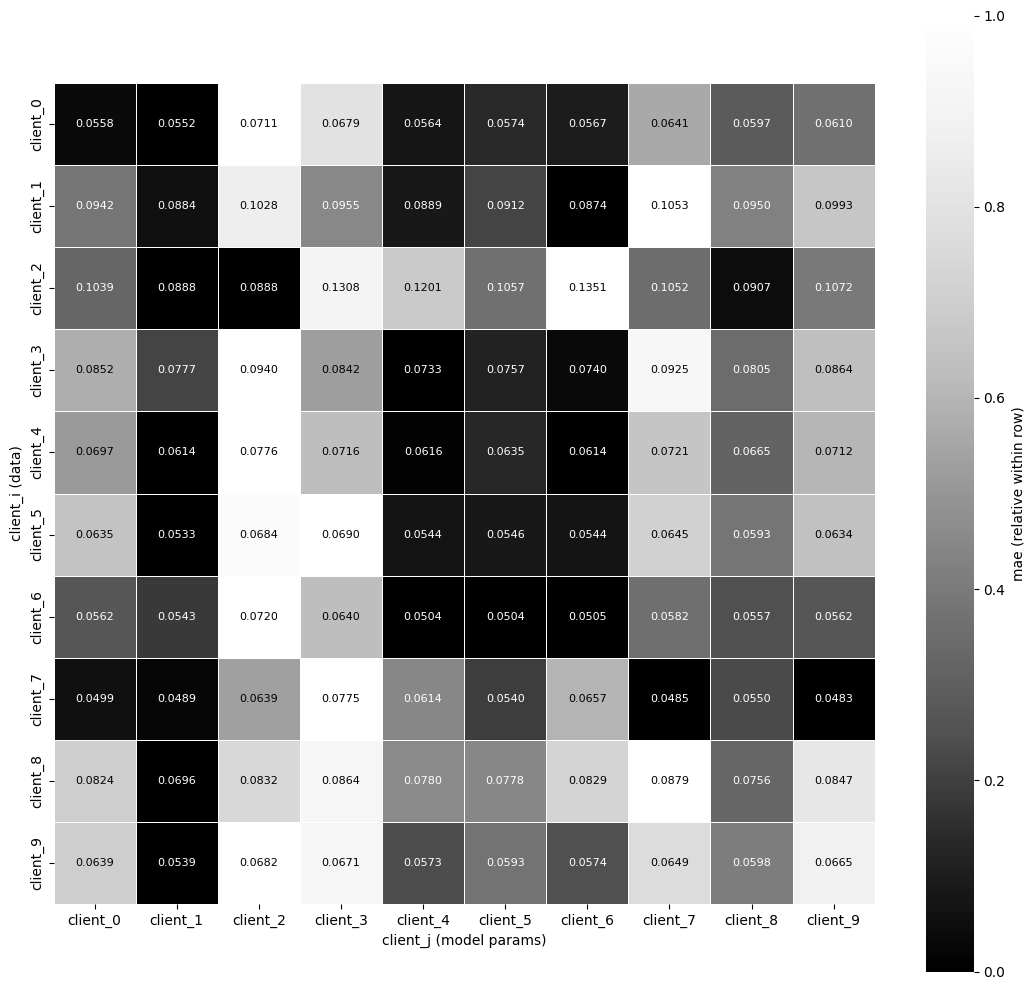

In [34]:
# Row-relative black/white grid: lowest value in each row stands out
n = results_matrix.shape[0]
results_df = pd.DataFrame(
    results_matrix,
    index=[f"client_{i}" for i in range(n)],
    columns=[f"client_{j}" for j in range(n)],
)

data = results_df.to_numpy(dtype=float)

# Normalize colors within each row (keep annotations as original values)
row_min = np.nanmin(data, axis=1, keepdims=True)
row_max = np.nanmax(data, axis=1, keepdims=True)
row_range = row_max - row_min
row_range_safe = np.where(row_range == 0, 1.0, row_range)
data_norm = (data - row_min) / row_range_safe  # 0=min in row, 1=max in row

plt.figure(figsize=(0.8 * n + 3, 0.8 * n + 2))
ax = sns.heatmap(
    data_norm,
    annot=data,
    fmt=".4f",
    cmap="Greys_r",  # black=low (best), white=high (worst) within each row
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": f"{metric} (relative within row)"},
    xticklabels=results_df.columns,
    yticklabels=results_df.index,
    square=True,
    annot_kws={"fontsize": 8},
)

# Make annotation text readable: invert based on normalized shade
for i in range(n):
    for j in range(n):
        txt = ax.texts[i * n + j]
        shade = data_norm[i, j]
        txt.set_color("white" if shade < 0.5 else "black")

# ax.set_title(f"{metric} per-row relative heatmap (evaluating client_j params on client_i data)")
ax.set_xlabel("client_j (model params)")
ax.set_ylabel("client_i (data)")
plt.tight_layout()
plt.show()

In [17]:
[metrics_private[49][i][2]['mae'] for i in range(10)]

[0.05181950330734253,
 0.08985653519630432,
 0.08501796424388885,
 0.08264146745204926,
 0.060479532927274704,
 0.057558055967092514,
 0.05006038770079613,
 0.05046933889389038,
 0.07586497813463211,
 0.061232633888721466]